#  5G - DL- Multi-Layer Perceptron (MLP) - modeling, evaluation and comparison with ml models

# Step 0 — Imports & setup

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (roc_auc_score, log_loss, brier_score_loss,
                             classification_report, confusion_matrix)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.pipeline import Pipeline

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)

print("All imports successful.")

All imports successful.


# Step 1 — Load data & encode target

In [21]:
train_df = pd.read_csv("train_dataset_prepared.csv")
test_df  = pd.read_csv("test_dataset_prepared.csv")

le    = LabelEncoder()
y_all = le.fit_transform(train_df["slice Type"])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("Label mapping:", label_map)
print("Class distribution:", pd.Series(y_all).value_counts().to_dict())

Label mapping: {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(3): np.int64(2)}
Class distribution: {0: 4772, 2: 2098, 1: 2088}


# Step 2 — Clean feature selection

In [22]:
# Same 4 clean network condition features as all other notebooks
clean_cols = ["Time", "Packet Loss Rate", "Packet delay", "LTE/5g Category"]

X_raw_train = train_df[clean_cols].copy()
X_raw_test  = test_df[clean_cols].copy()

print("Clean features:", clean_cols)
print("Train shape:", X_raw_train.shape)

Clean features: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category']
Train shape: (8958, 4)


# Step 3 — Feature engineering

In [23]:
def engineer_features(df):
    df = df.copy()
    
    # Interaction: delay + loss together describe link quality
    df["delay_x_loss"]   = df["Packet delay"] * df["Packet Loss Rate"]
    
    # Ratio: congestion vs packet error signal
    df["delay_per_loss"] = df["Packet delay"] / (df["Packet Loss Rate"] + 1e-6)
    
    # Network category weighted delay
    df["category_delay"] = df["LTE/5g Category"] * df["Packet delay"]
    
    # Log-transform skewed features
    df["log_packet_loss"]  = np.log1p(df["Packet Loss Rate"])
    df["log_packet_delay"] = np.log1p(df["Packet delay"])
    
    return df

X_all  = engineer_features(X_raw_train)
X_test = engineer_features(X_raw_test)

print(f"Features after engineering: {X_all.shape[1]}")
print(f"Feature names: {X_all.columns.tolist()}")

Features after engineering: 9
Feature names: ['Time', 'Packet Loss Rate', 'Packet delay', 'LTE/5g Category', 'delay_x_loss', 'delay_per_loss', 'category_delay', 'log_packet_loss', 'log_packet_delay']


# Step 4 — Three-way split

In [24]:
# Identical split structure to RF and XGB/LGB notebooks
# Same random_state=42 ensures comparable eval sets across all models

X_tr, X_temp, y_tr, y_temp = train_test_split(
    X_all, y_all,
    test_size=0.30,
    random_state=42,
    stratify=y_all
)

X_cal, X_eval, y_cal, y_eval = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"Train:       {X_tr.shape[0]} samples ({X_tr.shape[0]/len(X_all):.0%})")
print(f"Calibration: {X_cal.shape[0]} samples ({X_cal.shape[0]/len(X_all):.0%})")
print(f"Evaluation:  {X_eval.shape[0]} samples ({X_eval.shape[0]/len(X_all):.0%})")
print(f"\nTrain class distribution: {pd.Series(y_tr).value_counts().to_dict()}")

Train:       6270 samples (70%)
Calibration: 1344 samples (15%)
Evaluation:  1344 samples (15%)

Train class distribution: {0: 3340, 2: 1468, 1: 1462}


# Step 5 — Scaling (mandatory for MLP)

In [25]:
# Tree models don't need scaling — MLP absolutely does.
# Fit scaler ONLY on training data, transform cal/eval/test separately.
# This prevents data leakage through the scaler.

scaler = StandardScaler()

X_tr_scaled   = scaler.fit_transform(X_tr)    # fit + transform on train only
X_cal_scaled  = scaler.transform(X_cal)        # transform only
X_eval_scaled = scaler.transform(X_eval)       # transform only
X_test_scaled = scaler.transform(X_test)       # transform only

print("Scaling applied.")
print(f"Train mean (should be ~0): {X_tr_scaled.mean(axis=0).round(3)}")
print(f"Train std  (should be ~1): {X_tr_scaled.std(axis=0).round(3)}")

Scaling applied.
Train mean (should be ~0): [-0.  0.  0. -0. -0.  0.  0. -0.  0.]
Train std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1.]


# Step 6 — MLP baseline (before tuning)

In [26]:
# Modest baseline — 2 hidden layers, relu activation, adam optimizer
# max_iter=500 with early_stopping=True prevents overfitting
# validation_fraction uses part of training data to monitor convergence

mlp_base = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # 2 layers: 64 neurons then 32
    activation="relu",
    solver="adam",
    alpha=0.001,                   # L2 regularization
    learning_rate_init=0.001,
    max_iter=500,
    early_stopping=True,           # stops when val loss stops improving
    validation_fraction=0.1,       # 10% of X_tr used for early stopping
    n_iter_no_change=20,           # patience = 20 epochs
    random_state=42
)

mlp_base.fit(X_tr_scaled, y_tr)

y_prob_base = mlp_base.predict_proba(X_cal_scaled)
print("MLP Baseline (uncalibrated):")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_base, multi_class='ovr', average='macro'):.4f}")
print(f"  Log-loss: {log_loss(y_cal, y_prob_base):.4f}")
print(f"  Iterations run: {mlp_base.n_iter_}")

MLP Baseline (uncalibrated):
  AUC-ROC:  0.9952
  Log-loss: 0.0847
  Iterations run: 37


# Step 7 — Optuna hyperparameter tuning

In [29]:
# MLP-specific search space:
# - Architecture: number of layers and neurons per layer
# - Regularization: alpha (L2), early stopping patience
# - Learning rate and solver
# We use 3-fold CV inside each trial — same approach as RF notebook

def mlp_objective(trial):
    
    # Architecture — how many layers and how wide
    n_layers = trial.suggest_int("n_layers", 1, 4)
    layer_size = trial.suggest_categorical("layer_size", [32, 64, 128, 256])
    hidden_layers = tuple([layer_size] * n_layers)
    
    params = {
        "hidden_layer_sizes":  hidden_layers,
        "activation":          trial.suggest_categorical("activation",
                                                          ["relu", "tanh"]),
        "solver":              "adam",
        "alpha":               trial.suggest_float("alpha", 1e-5, 0.1, log=True),
        "learning_rate_init":  trial.suggest_float("learning_rate_init",
                                                    1e-4, 0.01, log=True),
        "max_iter":            500,
        "early_stopping":      True,
        "validation_fraction": 0.1,
        "n_iter_no_change":    trial.suggest_int("n_iter_no_change", 10, 30),
        "random_state":        42
    }
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    ll_scores = []
    
    for tr_idx, val_idx in skf.split(X_tr_scaled, y_tr):
        m = MLPClassifier(**params)
        m.fit(X_tr_scaled[tr_idx], y_tr[tr_idx])
        prob = m.predict_proba(X_tr_scaled[val_idx])
        ll_scores.append(log_loss(y_tr[val_idx], prob))
    
    return np.mean(ll_scores)

study_mlp = optuna.create_study(direction="minimize")
study_mlp.optimize(mlp_objective, n_trials=40)

print("\nBest params:", study_mlp.best_params)
print(f"Best CV log-loss: {study_mlp.best_value:.4f}")


Best params: {'n_layers': 4, 'layer_size': 128, 'activation': 'relu', 'alpha': 4.8978853900339446e-05, 'learning_rate_init': 0.0048979517735229456, 'n_iter_no_change': 20}
Best CV log-loss: 0.0772


# Step 8 — Train final tuned MLP

MLP Tuned (uncalibrated, on cal set):
  AUC-ROC:  0.9953
  Log-loss: 0.0771
  Architecture: (128, 128, 128, 128)
  Iterations run: 24


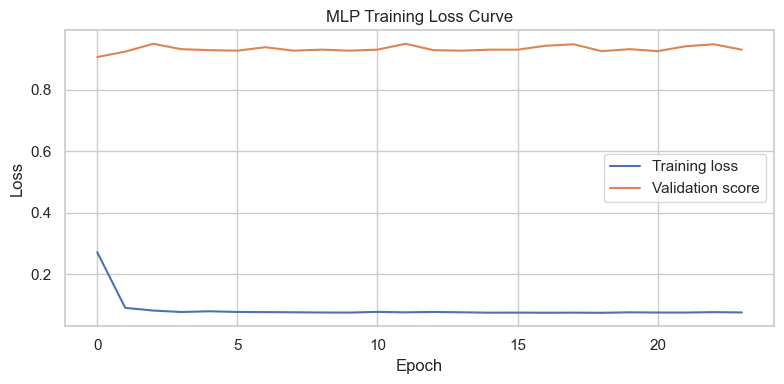

In [32]:
# Reconstruct hidden_layer_sizes from best params
best_p        = study_mlp.best_params
hidden_layers = tuple([best_p["layer_size"]] * best_p["n_layers"])

mlp_tuned = MLPClassifier(
    hidden_layer_sizes  = hidden_layers,
    activation          = best_p["activation"],
    solver              = "adam",
    alpha               = best_p["alpha"],
    learning_rate_init  = best_p["learning_rate_init"],
    n_iter_no_change    = best_p["n_iter_no_change"],
    max_iter            = 500,
    early_stopping      = True,
    validation_fraction = 0.1,
    random_state        = 42
)

mlp_tuned.fit(X_tr_scaled, y_tr)

y_prob_tuned = mlp_tuned.predict_proba(X_cal_scaled)
print("MLP Tuned (uncalibrated, on cal set):")
print(f"  AUC-ROC:  {roc_auc_score(y_cal, y_prob_tuned, multi_class='ovr', average='macro'):.4f}")
print(f"  Log-loss: {log_loss(y_cal, y_prob_tuned):.4f}")
print(f"  Architecture: {hidden_layers}")
print(f"  Iterations run: {mlp_tuned.n_iter_}")

# Training loss curve — useful to check for overfitting
plt.figure(figsize=(8, 4))
plt.plot(mlp_tuned.loss_curve_, label="Training loss")
if hasattr(mlp_tuned, "validation_scores_"):
    plt.plot(mlp_tuned.validation_scores_, label="Validation score")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Training Loss Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Step 9 — 5-fold cross-validation

In [33]:
# Important: scaler must be inside the CV loop to avoid leakage
# We use a Pipeline to ensure scaling is refit on each fold's train data

from sklearn.pipeline import Pipeline

skf5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores, ll_scores = [], []

# Rebuild best params for pipeline
best_p        = study_mlp.best_params
hidden_layers = tuple([best_p["layer_size"]] * best_p["n_layers"])

mlp_params = {
    "hidden_layer_sizes":  hidden_layers,
    "activation":          best_p["activation"],
    "solver":              "adam",
    "alpha":               best_p["alpha"],
    "learning_rate_init":  best_p["learning_rate_init"],
    "n_iter_no_change":    best_p["n_iter_no_change"],
    "max_iter":            500,
    "early_stopping":      True,
    "validation_fraction": 0.1,
    "random_state":        42
}

print("5-Fold CV (MLP with scaling inside each fold):")
for fold, (tr_idx, val_idx) in enumerate(skf5.split(X_all, y_all)):
    
    # Scale inside the fold — prevents leakage
    sc = StandardScaler()
    X_fold_tr  = sc.fit_transform(X_all.iloc[tr_idx])
    X_fold_val = sc.transform(X_all.iloc[val_idx])
    y_fold_tr  = y_all[tr_idx]
    y_fold_val = y_all[val_idx]
    
    m = MLPClassifier(**mlp_params)
    m.fit(X_fold_tr, y_fold_tr)
    prob = m.predict_proba(X_fold_val)
    
    auc = roc_auc_score(y_fold_val, prob, multi_class='ovr', average='macro')
    ll  = log_loss(y_fold_val, prob)
    auc_scores.append(auc)
    ll_scores.append(ll)
    print(f"  Fold {fold+1}: AUC={auc:.4f}  LogLoss={ll:.4f}")

print(f"\nCV Summary:")
print(f"  AUC:     {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")
print(f"  LogLoss: {np.mean(ll_scores):.4f} ± {np.std(ll_scores):.4f}")

5-Fold CV (MLP with scaling inside each fold):
  Fold 1: AUC=0.9942  LogLoss=0.0813
  Fold 2: AUC=0.9949  LogLoss=0.0777
  Fold 3: AUC=0.9961  LogLoss=0.0741
  Fold 4: AUC=0.9954  LogLoss=0.0724
  Fold 5: AUC=0.9940  LogLoss=0.0811

CV Summary:
  AUC:     0.9949 ± 0.0008
  LogLoss: 0.0773 ± 0.0036


# Step 10 — Probability calibration

Before calibration — log-loss: 0.0771
After calibration  — log-loss: 0.0836


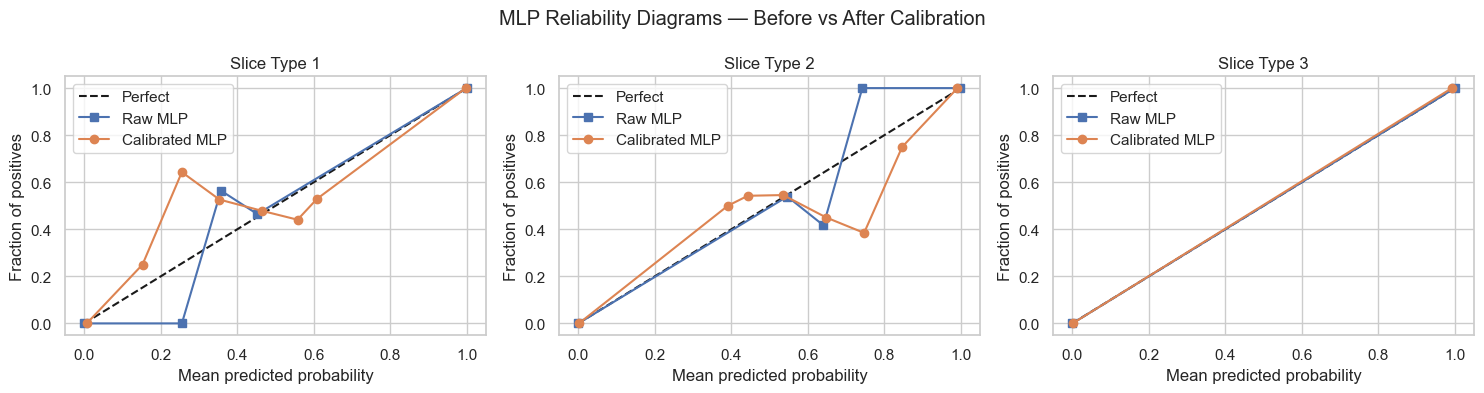


Brier Score per class:
  Slice 1 — raw: 0.0275  calibrated: 0.0289
  Slice 2 — raw: 0.0274  calibrated: 0.0289
  Slice 3 — raw: 0.0000  calibrated: 0.0000


In [34]:
# MLP softmax outputs are generally better calibrated than RF,
# but still worth checking and correcting.
# Use sigmoid (Platt scaling) — works well for neural networks.

calibrated_mlp = CalibratedClassifierCV(
    FrozenEstimator(mlp_tuned),
    method="sigmoid"
)
calibrated_mlp.fit(X_cal_scaled, y_cal)

y_prob_raw = mlp_tuned.predict_proba(X_cal_scaled)
y_prob_cal = calibrated_mlp.predict_proba(X_cal_scaled)

print(f"Before calibration — log-loss: {log_loss(y_cal, y_prob_raw):.4f}")
print(f"After calibration  — log-loss: {log_loss(y_cal, y_prob_cal):.4f}")

# Reliability diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for class_idx in range(3):
    y_bin = (y_cal == class_idx).astype(int)
    frac_raw, mean_raw = calibration_curve(y_bin, y_prob_raw[:, class_idx], n_bins=10)
    frac_cal, mean_cal = calibration_curve(y_bin, y_prob_cal[:, class_idx], n_bins=10)
    ax = axes[class_idx]
    ax.plot([0,1],[0,1],'k--', label="Perfect")
    ax.plot(mean_raw, frac_raw, 's-', label="Raw MLP")
    ax.plot(mean_cal, frac_cal, 'o-', label="Calibrated MLP")
    ax.set_title(f"Slice Type {class_idx+1}")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Fraction of positives")
    ax.legend()

plt.suptitle("MLP Reliability Diagrams — Before vs After Calibration")
plt.tight_layout()
plt.show()

# Brier scores
print("\nBrier Score per class:")
for i in range(3):
    y_bin  = (y_cal == i).astype(int)
    bs_raw = brier_score_loss(y_bin, y_prob_raw[:, i])
    bs_cal = brier_score_loss(y_bin, y_prob_cal[:, i])
    print(f"  Slice {i+1} — raw: {bs_raw:.4f}  calibrated: {bs_cal:.4f}")

# Step 11 — Final evaluation on unseen eval set

  FINAL EVALUATION — unseen holdout set (MLP)

AUC-ROC (macro OvR): 0.9954
Log-loss:            0.0847

Brier Score per class:
  Slice 1: 0.0291
  Slice 2: 0.0291
  Slice 3: 0.0000

Classification Report:
              precision    recall  f1-score   support

     Slice 1       0.95      0.96      0.95       716
     Slice 2       0.90      0.88      0.89       313
     Slice 3       1.00      1.00      1.00       315

    accuracy                           0.95      1344
   macro avg       0.95      0.95      0.95      1344
weighted avg       0.95      0.95      0.95      1344



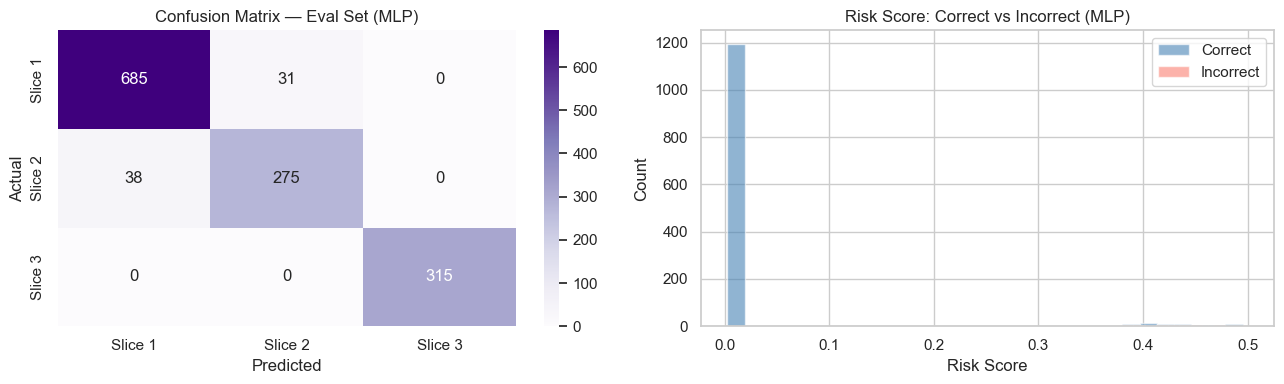


Risk score summary:
  Mean:                0.0484
  High-risk (> 0.20):  140 (10.4%)
  Low-risk  (< 0.05):  1192 (88.7%)

Among high-risk predictions:
  Accuracy: 53.6%  ← model correctly flags its own uncertainty


In [35]:
y_prob_eval = calibrated_mlp.predict_proba(X_eval_scaled)
y_pred_eval = y_prob_eval.argmax(axis=1)
class_names = [f"Slice {le.inverse_transform([i])[0]}" for i in range(3)]

print("=" * 55)
print("  FINAL EVALUATION — unseen holdout set (MLP)")
print("=" * 55)

auc_final = roc_auc_score(y_eval, y_prob_eval, multi_class='ovr', average='macro')
ll_final  = log_loss(y_eval, y_prob_eval)

print(f"\nAUC-ROC (macro OvR): {auc_final:.4f}")
print(f"Log-loss:            {ll_final:.4f}")

print("\nBrier Score per class:")
for i, name in enumerate(class_names):
    bs = brier_score_loss((y_eval == i).astype(int), y_prob_eval[:, i])
    print(f"  {name}: {bs:.4f}")

print("\nClassification Report:")
print(classification_report(y_eval, y_pred_eval, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

cm = confusion_matrix(y_eval, y_pred_eval)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names,
            yticklabels=class_names, ax=axes[0])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title("Confusion Matrix — Eval Set (MLP)")

risk_scores = 1 - y_prob_eval.max(axis=1)
correct     = y_eval == y_pred_eval
axes[1].hist(risk_scores[correct],  bins=30, alpha=0.6,
             label="Correct",   color="steelblue")
axes[1].hist(risk_scores[~correct], bins=30, alpha=0.6,
             label="Incorrect", color="salmon")
axes[1].set_xlabel("Risk Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Risk Score: Correct vs Incorrect (MLP)")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nRisk score summary:")
print(f"  Mean:                {risk_scores.mean():.4f}")
print(f"  High-risk (> 0.20):  {(risk_scores > 0.20).sum()} ({(risk_scores > 0.20).mean():.1%})")
print(f"  Low-risk  (< 0.05):  {(risk_scores < 0.05).sum()} ({(risk_scores < 0.05).mean():.1%})")

high_risk_mask = risk_scores > 0.20
if high_risk_mask.sum() > 0:
    hr_acc = correct[high_risk_mask].mean()
    print(f"\nAmong high-risk predictions:")
    print(f"  Accuracy: {hr_acc:.1%}  ← model correctly flags its own uncertainty")

# Step 12 — Final comparison: MLP vs RF vs XGBoost vs LightGBM

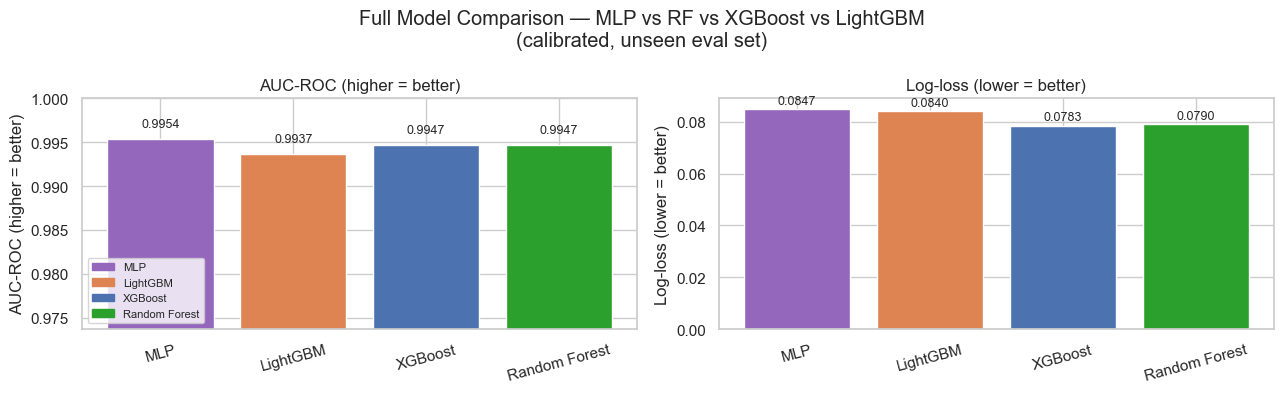


Full comparison table:
        Model      AUC  LogLoss
          MLP 0.995375 0.084743
      XGBoost 0.994700 0.078300
Random Forest 0.994700 0.079000
     LightGBM 0.993700 0.084000


In [36]:

results_comparison = pd.DataFrame([
    {"Model": "MLP",            "AUC": auc_final, "LogLoss": ll_final},
    {"Model": "LightGBM",       "AUC": 0.9937,    "LogLoss": 0.0840},  
    {"Model": "XGBoost",        "AUC": 0.9947,    "LogLoss": 0.0783},  
    {"Model": "Random Forest",  "AUC": 0.9947,    "LogLoss": 0.0790},  
])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ["#9467bd", "#DD8452", "#4C72B0", "#2ca02c"]
# purple=MLP, orange=LGB, blue=XGB, green=RF

for ax, metric, title, better in zip(
    axes,
    ["AUC", "LogLoss"],
    ["AUC-ROC (higher = better)", "Log-loss (lower = better)"],
    ["max", "min"]
):
    bars = ax.bar(results_comparison["Model"],
                  results_comparison[metric], color=colors)
    if better == "max":
        ax.set_ylim(results_comparison[metric].min() - 0.02, 1.0)
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, results_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f"{val:.4f}", ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#9467bd", label="MLP"),
    Patch(color="#DD8452", label="LightGBM"),
    Patch(color="#4C72B0", label="XGBoost"),
    Patch(color="#2ca02c", label="Random Forest"),
]
axes[0].legend(handles=legend_handles, fontsize=8)

plt.suptitle("Full Model Comparison — MLP vs RF vs XGBoost vs LightGBM\n(calibrated, unseen eval set)")
plt.tight_layout()
plt.show()

print("\nFull comparison table:")
print(results_comparison.sort_values("AUC", ascending=False).to_string(index=False))